In [189]:
import numpy as np
import pandas as pd
from scipy.constants import k as k_B
import matplotlib.pyplot as plt
from scipy import stats

In [190]:
def collectSamples(folder, number_of_elements, runs):
  temperatures = np.zeros((number_of_elements * runs), dtype=float)
  for i in range(runs):
    temperatures[i * number_of_elements:(i + 1) * number_of_elements] = pd.read_csv(f"{folder}/run_{i:d}_element_temperatures_0001.csv")["temperature"].to_numpy()
  return temperatures

temperature_data = collectSamples("data", 100, 40)


In [191]:
def histogramFromData(data, bins=50):
    hist = np.histogram(data, bins=bins, density=True)
    values = hist[0]
    centers = (hist[1][1:] + hist[1][:-1]) / 2.0
    widths = hist[1][1:] - hist[1][:-1]
    return values, centers, widths

values, centers, widths = histogramFromData(temperature_data, bins=25)

In [192]:
def actualVSExpectedVariance(actual_mean, data, particles_averaged):
  num_samples = len(data)
  measured_mean = data.mean()
  measured_relative_var = np.sqrt(((data - actual_mean)**2).sum() / num_samples) / actual_mean
  expected_relative_var = np.sqrt(2 / (3 * particles_averaged))


  print(f"Expected Mean : {actual_mean:0.4E}")
  print(f"Measured Mean : {measured_mean:0.4E}")
  print(f"Percent Error : {np.abs(measured_mean - actual_mean) * 100 / actual_mean:0.4E} %")
  print(f"Expected Relative Var  : {expected_relative_var:0.4E}")
  print(f"Measured Relative Var  : {measured_relative_var:0.4E}")
  print(f"Percent Error : {np.abs(measured_relative_var - expected_relative_var) * 100 / expected_relative_var:0.4E} %")


T_true = 273.15
actualVSExpectedVariance(T_true, temperature_data, 10)

Expected Mean : 2.7315E+02
Measured Mean : 2.7569E+02
Percent Error : 9.3131E-01 %
Expected Relative Var  : 2.5820E-01
Measured Relative Var  : 2.6020E-01
Percent Error : 7.7681E-01 %


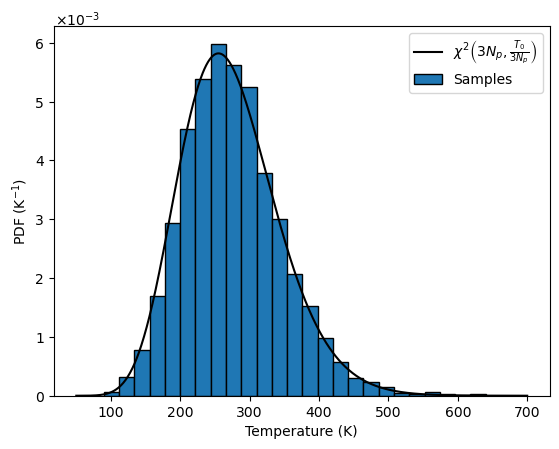

In [193]:
T_range = np.linspace(50, 700, 1000)
ppe = 10
plt.figure()
plt.bar(centers, values * 1e3, widths, edgecolor='k', label='Samples')
plt.plot(T_range, stats.chi2.pdf(T_range, df=3 * ppe, scale=T_true / (3 * ppe)) * 1e3, '-k', label='$\\chi^2 \\left(3 N_p,\\frac{T_0}{3 N_p}\\right)$')
plt.xlabel("Temperature (K)")
plt.ylabel("PDF (K$^{-1}$)")
plt.text(20, 6.3, "$\\times10^{-3}$")
plt.legend()
plt.show()